# Домашнее задание 4. Механизм внимания и архитектура Transformer


## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

| Уровень | Задачи | Баллы |
|---------|--------|-------|
| **Простые** | 1—4 | 3 (0.75 за задачу) |
| **Средние** | 5—7 | 3 (1 за задачу) |
| **Сложные** | 8—9 | 4 (2 за задачу) |

**Итого:** 10 баллов

## Настройка окружения

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, Dataset
import seaborn as sns
import math
import copy
import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

Device: cpu


---

## Теоретический минимум

### Ограничения рекуррентных сетей (RNN)

RNN обрабатывают последовательность **последовательно**: $h_t = f(h_{t-1}, x_t)$.

Проблемы:
- Нельзя параллелизовать вычисления по позициям.
- Затухание/взрыв градиентов при длинных последовательностях (BPTT).
- Плохое моделирование дальних зависимостей.

### Идея внимания (Attention)

Вместо сжатия всей последовательности в один вектор — разрешить модели
«смотреть» на все позиции входа одновременно, взвешивая их по релевантности.

### Queries, Keys, Values

Входная последовательность $X \in \mathbb{R}^{N \times D}$ проецируется в три пространства:

$$Q = X W_Q, \quad K = X W_K, \quad V = X W_V$$

где $W_Q, W_K \in \mathbb{R}^{D \times d_k}$, $W_V \in \mathbb{R}^{D \times d_v}$.

### Scaled Dot-Product Attention

$$\text{Attention}(Q, K, V) = \text{softmax}\!\left(\frac{Q K^T}{\sqrt{d_k}}\right) V$$

- $QK^T \in \mathbb{R}^{N \times N}$ — матрица «похожестей» между позициями.
- Деление на $\sqrt{d_k}$ предотвращает насыщение softmax при больших $d_k$.

### Multi-Head Attention

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1, \ldots, \text{head}_h)\,W_O$$

$$\text{head}_i = \text{Attention}(Q W_Q^i, K W_K^i, V W_V^i)$$

Разные головы захватывают разные типы зависимостей.

### Слой Transformer

```
x -> MultiHeadAttention -> Add & LayerNorm -> FFN -> Add & LayerNorm -> output
```

FFN: два линейных слоя с ReLU: $\text{FFN}(x) = \max(0, x W_1 + b_1) W_2 + b_2$.

### Позиционное кодирование

Без позиционной информации self-attention инвариантен к перестановкам.
Синусоидальное кодирование:

$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

### Causal Mask

Для авторегрессивных моделей (decoder) нужно запретить токену «видеть» будущие
позиции. Это достигается маской — нижнетреугольной матрицей.

### Токенизация

- **Word-level**: слова как токены. Большой словарь, проблема OOV.
- **Char-level**: символы как токены. Маленький словарь, длинные последовательности.
- **Subword (BPE)**: компромисс. Частые слова целиком, редкие — по частям.

### Вычислительная сложность

Self-attention: $O(N^2 \cdot d)$ по времени и $O(N^2)$ по памяти (матрица $N \times N$).
FFN: $O(N \cdot d \cdot d_{ff})$.


---

# ПРОСТЫЕ ЗАДАЧИ (1—4)

Понимание механизма attention: формулы, размерности, масштабирование.

## Задача 1. Ручной расчет attention на 3 токенах

### Постановка задачи

На маленьком примере (3 токена, $d_k = 4$) пошагово вычислите scaled dot-product attention.

### Задача
1. Задайте Q, K, V размерности (3, 4) вручную.
2. Вычислите $QK^T$, масштабируйте на $\sqrt{d_k}$, примените softmax, умножьте на $V$.
3. Покажите каждый промежуточный результат.
4. Сравните softmax с масштабированием и без — покажите, что без масштабирования распределение более «острое».


In [2]:
# Задача 1. Ручной расчет attention

# Зададим Q, K, V вручную (3 токена, d_k = 4)
Q = torch.tensor([[1.0, 0.0, 1.0, 0.0],
                   [0.0, 1.0, 0.0, 1.0],
                   [1.0, 1.0, 0.0, 0.0]], dtype=torch.float32)

K = torch.tensor([[1.0, 0.0, 0.0, 1.0],
                   [0.0, 1.0, 1.0, 0.0],
                   [1.0, 1.0, 1.0, 1.0]], dtype=torch.float32)

V = torch.tensor([[1.0, 2.0],
                   [3.0, 4.0],
                   [5.0, 6.0]], dtype=torch.float32)

# d_k - размерность, в которую спроецированы и запросы (Q), и ключи (K)
# Q и K имеют форму (3, 4), поэтому d_k можно взять как последнюю размерность любого из них
d_k = Q.shape[-1]   #4
print(f"d_k = {d_k}")

# Шаг 1. Вычисление оценок внимания QK^T
# Здесь мы считаем, насколько каждый запрос похож на каждый ключ
# Чем больше число, тем сильнее внимание
scores = Q @ K.T   # матрица 3×3
print("\nМатрица оценок внимания (Q @ K^T)")
print(scores)

# Шаг 2. Масштабирование (чтобы числа не были слишком большими для softmax)
scaled_scores = scores / (d_k ** 0.5)
print("\nМасштабирование")
print(scaled_scores)

# Шаг 3. Softmax (превращаем в вероятности)
weights = F.softmax(scaled_scores, dim=-1)
print("\nВеса внимания")
print(weights)

# Шаг 4. Умножение на V
result = weights @ V
print("\nНовые представления токенов после внимания")
print(result)

# Сравнение: без масштабирования
weights_without_scale = F.softmax(scores, dim=-1)
print("\nВеса без масштабирования")
print(weights_without_scale)
result_without_scale = weights_without_scale @ V
print("\nПредставления токенов (без масштабирования)")
print(result_without_scale)

d_k = 4

Матрица оценок внимания (Q @ K^T)
tensor([[1., 1., 2.],
        [1., 1., 2.],
        [1., 1., 2.]])

Масштабирование
tensor([[0.5000, 0.5000, 1.0000],
        [0.5000, 0.5000, 1.0000],
        [0.5000, 0.5000, 1.0000]])

Веса внимания
tensor([[0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519],
        [0.2741, 0.2741, 0.4519]])

Новые представления токенов после внимания
tensor([[3.3556, 4.3556],
        [3.3556, 4.3556],
        [3.3556, 4.3556]])

Веса без масштабирования
tensor([[0.2119, 0.2119, 0.5761],
        [0.2119, 0.2119, 0.5761],
        [0.2119, 0.2119, 0.5761]])

Представления токенов (без масштабирования)
tensor([[3.7284, 4.7284],
        [3.7284, 4.7284],
        [3.7284, 4.7284]])


**Вывод**

Получено, что все три токена имеют идентичные выходные векторы. Этот результат не является очевидным, поскольку разные входные токены в общем случае приводят к разным выходным представлениям. Однако вычисления показали, что матрица оценок внимания оказалась с одинаковыми строками, веса внимания совпали для всех запросов, и итоговые векторы стали неразличимы. Сравнение режимов с масштабированием и без него выявило, что деление на корень из d_k снижает остроту распределения: максимальный вес падает с 0.5761 до 0.4519.

---

## Задача 2. Реализация scaled dot-product attention

### Постановка задачи

Реализуйте функцию `scaled_dot_product_attention(Q, K, V, mask=None)`
и протестируйте на случайных данных.

### Задача
1. Реализуйте формулу: $\text{softmax}(QK^T / \sqrt{d_k}) \cdot V$.
2. Если mask задана, замените замаскированные позиции на $-10^9$ перед softmax.
3. Верните (output, attention_weights).
4. Проверьте: корректность форм, суммы softmax = 1.


In [3]:
# Задача 2. Scaled dot-product attention

def scaled_dot_product_attention(Q, K, V, mask=None):
    """
    Scaled dot-product attention.

    Аргументы:
        Q: (batch, seq_q, d_k)
        K: (batch, seq_k, d_k)
        V: (batch, seq_k, d_v)
        mask: (batch, seq_q, seq_k) или (seq_q, seq_k), 0 = маскировать

    Возвращает:
        output: (batch, seq_q, d_v)
        weights: (batch, seq_q, seq_k)
    """
    # Проверка: размерности d_k должны совпадать
    # Для умножения Q на K^T нужно, чтобы у них была одинаковая размерность признаков
    assert Q.shape[-1] == K.shape[-1]

    # Транспонируем K, чтобы поменять местами две последние размерности
    # Было: (batch, seq_k, d_k) -> Стало: (batch, d_k, seq_k)
    K_transposed = K.transpose(-2, -1)

    # Вычисляем матрицу оценок Q @ K^T
    scores = Q @ K_transposed

    # Масштабирование (делим на корень из d_k)
    d_k = Q.shape[-1]
    scaled_scores = scores / (d_k ** 0.5)

    # Применяем маску (если передана)
    if mask is not None:
        # Заменяем замаскированные позиции на очень маленькое число
        scaled_scores = scaled_scores.masked_fill(mask == 0, -1e9)

    # Softmax по последнему измерению (по ключам)
    weights = F.softmax(scaled_scores, dim=-1)

    # Умножаем на V
    output = weights @ V

    return output, weights

# --- Тестирование ---

# Параметры для тестирования
batch_size = 2   # 2 предложения в батче
seq_q = 5        # длина последовательности запросов (5 слов)
seq_k = 5        # длина последовательности ключей (5 слов)
d_k = 4          # размерность ключей (как в Transformer base)
d_v = 4          # размерность значений

# Создаем случайные тензоры
Q = torch.randn(batch_size, seq_q, d_k)
K = torch.randn(batch_size, seq_k, d_k)
V = torch.randn(batch_size, seq_k, d_v)

# Вызываем функцию
output, weights = scaled_dot_product_attention(Q, K, V)

print(f"Q shape: {Q.shape}")
print(f"K shape: {K.shape}")
print(f"V shape: {V.shape}")
print(f"Output shape: {output.shape}")
print(f"Weights shape: {weights.shape}")
print()

# Проверка: суммы softmax = 1
row_sums = weights.sum(dim=-1)
# Выводим все строки для первого элемента батча
print("Первый элемент батча:")
for i in range(row_sums.shape[1]):
    print(f"Строка {i}: {row_sums[0, i].item():.4f}")

# Выводим все строки для второго элемента батча
print("\nВторой элемент батча:")
for i in range(row_sums.shape[1]):
    print(f"Строка {i}: {row_sums[1, i].item():.4f}")
print()

# С маской
# Causal mask (нижнетреугольная матрица) запрещает токенам смотреть
# на будущие позиции, что необходимо для генерации текста
# torch.tril оставляет нижний треугольник матрицы (включая диагональ),
# а верхний треугольник заменяет на ноль
seq_len = 5
causal_mask = torch.tril(torch.ones(seq_len, seq_len))
print("Causal mask (1 - можно смотреть, 0 - нельзя):")
print(causal_mask)

mask_output, mask_wights = scaled_dot_product_attention(Q, K, V,
                                                             mask=causal_mask)
print(f"\nВеса внимания с маской")
print(mask_wights)
print(f"\nРезультат внимания с маской")
print(mask_output)

Q shape: torch.Size([2, 5, 4])
K shape: torch.Size([2, 5, 4])
V shape: torch.Size([2, 5, 4])
Output shape: torch.Size([2, 5, 4])
Weights shape: torch.Size([2, 5, 5])

Первый элемент батча:
Строка 0: 1.0000
Строка 1: 1.0000
Строка 2: 1.0000
Строка 3: 1.0000
Строка 4: 1.0000

Второй элемент батча:
Строка 0: 1.0000
Строка 1: 1.0000
Строка 2: 1.0000
Строка 3: 1.0000
Строка 4: 1.0000

Causal mask (1 - можно смотреть, 0 - нельзя):
tensor([[1., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0.],
        [1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1.]])

Веса внимания с маской
tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.4436, 0.5564, 0.0000, 0.0000, 0.0000],
         [0.1045, 0.2732, 0.6223, 0.0000, 0.0000],
         [0.2218, 0.0984, 0.5620, 0.1178, 0.0000],
         [0.0691, 0.1656, 0.1001, 0.4584, 0.2068]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.2189, 0.7811, 0.0000, 0.0000, 0.0000],
         [0.2703, 0.0846, 0.6450, 0.0

**Вывод**

Реализована функция scaled_dot_product_attention, описывающая механизм внимания. Она корректно вычисляет оценки Q @ K^T, применяет масштабирование делением на корень из d_k, обрабатывает маску (заменяя запрещенные позиции на -10^9) и через softmax получает веса внимания, сумма которых равна единице. Итоговый результат представляет собой взвешенную сумму значений V. Тесты с causal mask подтверждают, что механизм внимания ограничивает видимость будущих позиций.

---

## Задача 3. Маскирование: causal mask и padding mask

### Постановка задачи

Реализуйте два типа масок и покажите их влияние на веса внимания.

### Задача
1. `causal_mask(seq_len)`: нижнетреугольная матрица (запрет на «будущие» позиции).
2. `padding_mask(lengths, max_len)`: маска для последовательностей разной длины.
3. Визуализируйте обе маски как heatmap.
4. Покажите attention weights с causal mask и без.


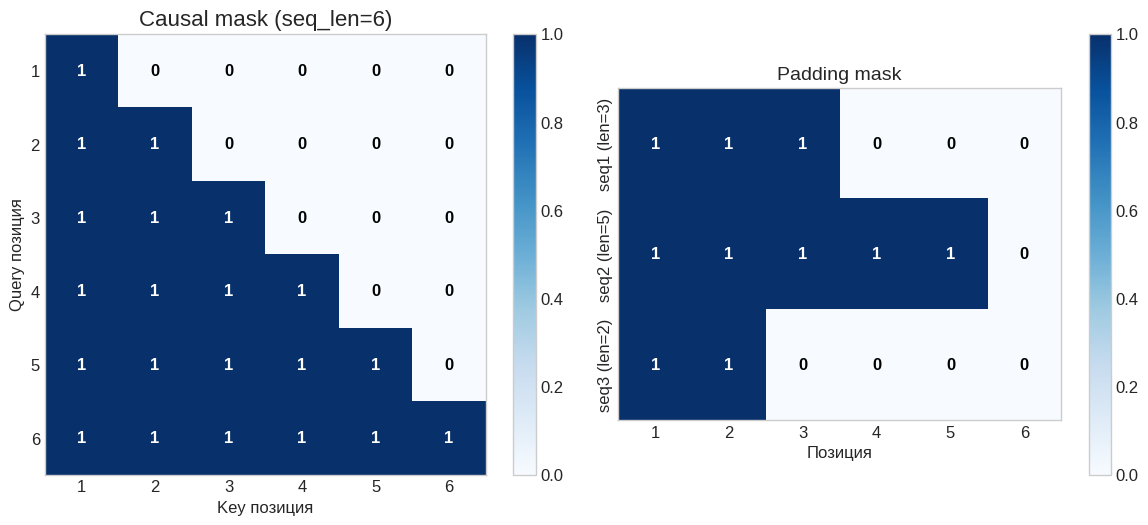

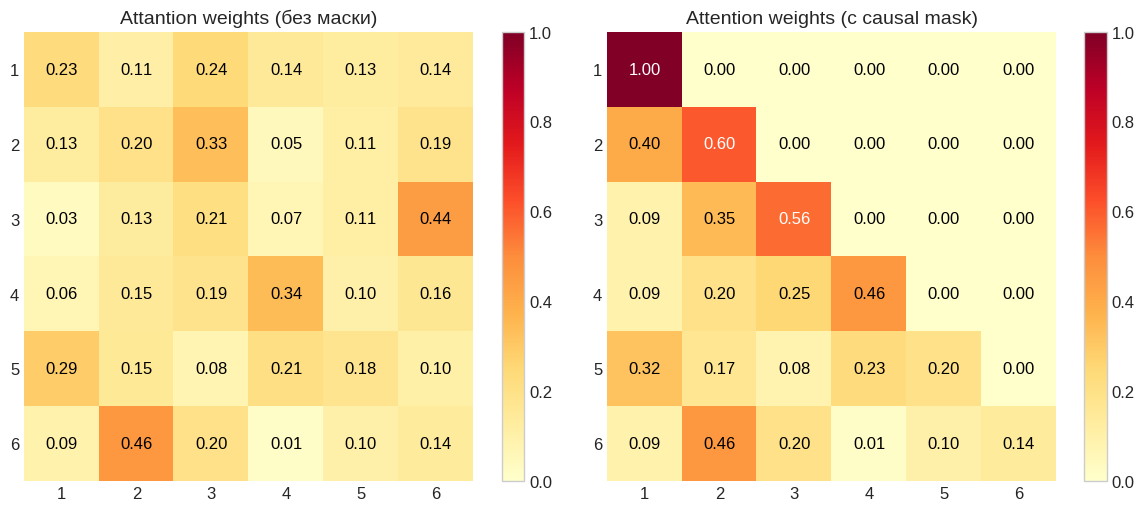

Вывод: 
causal mask обнуляет внимание к будущим позициям,
что необходимо для авторегрессивной генерации.


In [4]:
# Задача 3. Causal mask и padding mask

def causal_mask(seq_len):
    """Нижнетреугольная маска (1 = разрешено, 0 = запрещено)"""

    # assert проверяет, что seq_len - положительное целое число
    assert isinstance(seq_len, int) and seq_len > 0, "seq_len должно быть положительным целым числом"

    # torch.ones(seq_len, seq_len) создает квадратную матрицу из единиц
    # torch.tril оставляет только нижний треугольник (включая диагональ)
    # Верхний треугольник становится нулями
    mask = torch.tril(torch.ones(seq_len, seq_len))
    return mask

def padding_mask(lengths, max_len):
    """Маска для padding: lengths --- длины последовательностей в батче"""

    # Проверка, что все длины не превышают max_len
    assert all(l <= max_len for l in lengths), "Длина не может превышать max_len"

    # Создаем матрицу из нулей
    # Количество строк = число предложений в батче (len(lengths))
    # Количество столбцов = максимальная длина последовательности (max_len)
    mask = torch.zeros(len(lengths), max_len)

    # Для каждого предложения в батче
    for i, length in enumerate(lengths):
        # Заполняем единицами первые 'length' позиций (реальные токены)
        # Остальные позиции остаются нулями (PAD токены, их нужно игнорировать)
        mask[i, :length] = 1

    return mask

# Визуализация масок

# Causal mask для 6 токенов
seq_len = 6
causal = causal_mask(seq_len)

# Padding mask для 3 предложений (длины: 3, 5, 2)
lengths = [3, 5, 2]
max_len = 6
padding = padding_mask(lengths, max_len)

# Рисуем две тепловые карты
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Causal mask
im1 = axes[0].imshow(causal, cmap='Blues', vmin=0, vmax=1)
axes[0].set_title('Causal mask (seq_len=6)', fontsize=16)
axes[0].set_xlabel('Key позиция', fontsize=12)
axes[0].set_ylabel('Query позиция', fontsize=12)

# Подписываем оси цифрами 1-6
axes[0].set_xticks(range(seq_len))
axes[0].set_xticklabels(range(1, seq_len + 1))
axes[0].set_yticks(range(seq_len))
axes[0].set_yticklabels(range(1, seq_len + 1))

# Отключаем сетку
axes[0].grid(False)

# Вписываем значения в ячейки
for i in range(seq_len):
    for j in range(seq_len):
        value = int(causal[i, j].item())
        axes[0].text(j, i, f'{value}', ha='center', va='center',
                     fontsize=12, fontweight='bold',
                     color='white' if value == 1 else 'black')

plt.colorbar(im1, ax=axes[0])

# Padding mask
im2 = axes[1].imshow(padding, cmap='Blues', vmin=0, vmax=1, aspect=1.5)
axes[1].set_title('Padding mask', fontsize=14)
axes[1].set_xlabel('Позиция', fontsize=12)

# Подписываем строки (предложения) с их длинами
row_labels = [f'seq1 (len={lengths[0]})', f'seq2 (len={lengths[1]})', f'seq3 (len={lengths[2]})']
axes[1].set_yticks(range(len(lengths)))
axes[1].set_yticklabels(row_labels, rotation=90, fontsize=12, va='center')

# Подписываем столбцы (позиции) цифрами 1-5
axes[1].set_xticks(range(max_len))
axes[1].set_xticklabels(range(1, max_len + 1))

# Отключаем сетку
axes[1].grid(False)

# Вписываем значения в ячейки
for i in range(len(lengths)):
    for j in range(max_len):
        value = int(padding[i, j].item())
        axes[1].text(j, i, f'{value}', ha='center', va='center',
                     fontsize=12, fontweight='bold',
                     color='white' if value == 1 else 'black')

plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

# Attention с causal mask и без

# Устанавливаем параметры для теста
batch_size = 1  # одно предложение в пакете (для простоты визуализации)
seq_len = 6     # длина последовательности: 6 токенов
d_k = 8         # размерность векторов ключей и запросов

# Создаём случайные тензоры Q, K, V
Q = torch.randn(batch_size, seq_len, d_k)
K = torch.randn(batch_size, seq_len, d_k)
V = torch.randn(batch_size, seq_len, d_k)

# Вычисляем веса внимания

# Без маски: все токены могут видеть все остальные токены
# Это режим энкодера (как в BERT) - каждый токен видит полный контекст
_, w_no_mask = scaled_dot_product_attention(Q, K, V)

# С causal mask токен не может видеть будущие позиции
# Создаём нижнетреугольную маску (1 - можно смотреть, 0 - нельзя)
causal = causal_mask(seq_len)
_, w_causal = scaled_dot_product_attention(Q, K, V, mask=causal)

# Визуализация весов внимания
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Веса без маски
im1 = axes[0].imshow(w_no_mask[0].detach(), cmap='YlOrRd', vmin=0, vmax=1)
axes[0].set_title('Attantion weights (без маски)', fontsize=14)

# Подписываем оси
axes[0].set_xticks(range(seq_len))
axes[0].set_xticklabels(range(1, seq_len + 1), fontsize=12)
axes[0].set_yticks(range(seq_len))
axes[0].set_yticklabels(range(1, seq_len + 1), fontsize=12)

# Отключаем сетку и рамку
axes[0].grid(False)
for spine in axes[0].spines.values():
    spine.set_visible(False)

# Вписываем значения
for i in range(seq_len):
    for j in range(seq_len):
        value = w_no_mask[0, i, j].item()
        color = 'white' if value > 0.5 else 'black'
        axes[0].text(j, i, f'{value:.2f}', ha='center', va='center',
                     fontsize=12, color=color)

plt.colorbar(im1, ax=axes[0])

# Веса c causal mask
im2 = axes[1].imshow(w_causal[0].detach(), cmap='YlOrRd', vmin=0, vmax=1)
axes[1].set_title('Attention weights (c causal mask)', fontsize=14)

# Подписываем оси
axes[1].set_xticks(range(seq_len))
axes[1].set_xticklabels(range(1, seq_len + 1), fontsize=12)
axes[1].set_yticks(range(seq_len))
axes[1].set_yticklabels(range(1, seq_len + 1), fontsize=12)

# Отключаем сетку и рамку
axes[1].grid(False)
for spine in axes[1].spines.values():
    spine.set_visible(False)

# Вписываем значения
for i in range(seq_len):
    for j in range(seq_len):
        value = w_causal[0, i, j].item()
        color = 'white' if value > 0.5 else 'black'
        axes[1].text(j, i, f'{value:.2f}', ha='center', va='center',
                     fontsize=12, color=color)

plt.colorbar(im2, ax=axes[1])
plt.tight_layout()
plt.show()

print("Вывод: ")
print("causal mask обнуляет внимание к будущим позициям,")
print("что необходимо для авторегрессивной генерации.")

---

## Задача 4. Позиционное кодирование

### Постановка задачи

Реализуйте синусоидальное позиционное кодирование и покажите,
что без него attention инвариантен к перестановкам.

### Формулы
$$PE(pos, 2i) = \sin\!\left(\frac{pos}{10000^{2i/d}}\right), \quad
PE(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

### Задача
1. Реализуйте `sinusoidal_pe(max_len, d_model)`.
2. Визуализируйте PE как heatmap.
3. Покажите, что без PE перестановка токенов не меняет attention output.


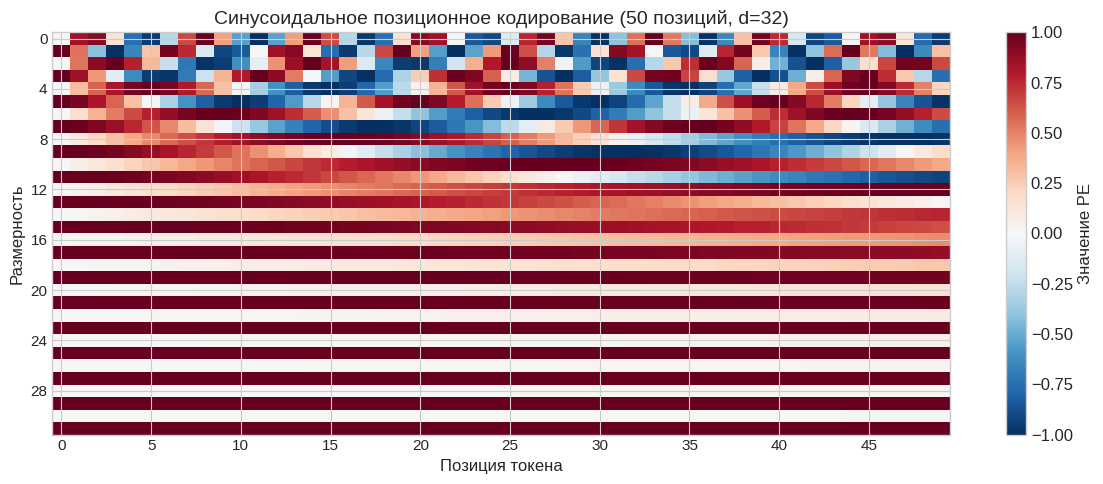

Максимальная разница без PE: 0.00000024
Без PE: attention инвариантен к перестановкам  [OK]
Максимальная разница с PE:   3.6141
С PE: перестановка МЕНЯЕТ результат  [OK]


In [5]:
# Задача 4. Позиционное кодирование

def sinusoidal_pe(max_len, d_model):
    """Синусоидальное позиционное кодирование"""
    # Проверка: d_model (размерность эмбеддингов) должна быть четной, чтобы можно было разделить на sin и cos
    assert d_model % 2 == 0, "d_model должно быть четным для синусоидального кодирования"

    # Создаем пустой тензор для позиционного кодирования (строки - позиции, столбцы - измерения)
    pe = torch.zeros(max_len, d_model)

    # Номера позиций: от 0 до max_len-1
    # unsqueeze(1) превращает (max_len) в (max_len, 1) для корректного умножения
    positions = torch.arange(0, max_len).unsqueeze(1).float()

    # Частоты для синусов и косинусов
    # Для каждого четного индекса i вычисляем: 10000^(2i/d_model)
    # Берем логарифм и экспоненту для численной устойчивости
    frequencies = torch.exp(torch.arange(0, d_model, 2).float() *
                        (-math.log(10000.0) / d_model))

    # Четные индексы заполняем синусом
    pe[:, 0::2] = torch.sin(positions * frequencies)

    # Нечетные индексы заполняем косинусом
    pe[:, 1::2] = torch.cos(positions * frequencies)

    return pe

# Визуализация

# Параметры
max_len = 50      # 50 позиций (50 токенов)
d_model = 32      # размерность эмбеддинга (32 числа на позицию)

# Вычисляем позиционное кодирование
pe = sinusoidal_pe(max_len, d_model)

# Транспонируем и переворачиваем по вертикали (для отображения как в примере)
pe_display = pe.numpy().T  # форма (32, 50)

# Создаём фигуру
plt.figure(figsize=(12, 5))

# Отображаем матрицу позиционного кодирования в виде тепловой карты
im = plt.imshow(pe_display, cmap='RdBu_r', aspect='auto', vmin=-1, vmax=1)

# Подписи осей
plt.xlabel('Позиция токена', fontsize=12)
plt.ylabel('Размерность', fontsize=12)

# Настройка делений по оси X (позиции)
plt.xticks(range(0, max_len, 5), range(0, max_len, 5), fontsize=11)

# Настройка делений по оси Y (размерности)
plt.yticks(range(0, d_model, 4), range(0, d_model, 4), fontsize=11)

# Добавляем цветовую шкалу
cbar = plt.colorbar(im)
cbar.set_label('Значение PE', fontsize=12)

# Заголовок
plt.title('Синусоидальное позиционное кодирование (50 позиций, d=32)',
          fontsize=14)

plt.tight_layout()
plt.show()

# --- Демонстрация: без PE перестановка не влияет на attention ---
SEED = 42
torch.manual_seed(SEED)
d_model = 16
seq_len = 4

# Случайные эмбеддинги (без позиции)
X = torch.randn(seq_len, d_model)

# Прямой порядок
out_orig, _ = scaled_dot_product_attention(X.unsqueeze(0), X.unsqueeze(0), X.unsqueeze(0))
out_orig = out_orig[0]

# Перемешиваем токены
perm = torch.randperm(seq_len)
X_perm = X[perm]
out_perm, _ = scaled_dot_product_attention(X_perm.unsqueeze(0), X_perm.unsqueeze(0), X_perm.unsqueeze(0))
out_perm = out_perm[0]

# Возвращаем исходный порядок для сравнения
inv_perm = torch.argsort(perm)
out_perm_restored = out_perm[inv_perm]

diff_no_pe = (out_orig - out_perm_restored).abs().max().item()
print(f"Максимальная разница без PE: {diff_no_pe:.8f}")
if diff_no_pe < 1e-6:
    print("Без PE: attention инвариантен к перестановкам  [OK]")
else:
    print("Без PE: attention НЕ инвариантен к перестановкам  [FAIL]")

# --- Демонстрация: с PE перестановка влияет на attention ---

pe_emb = sinusoidal_pe(seq_len, d_model)   # (seq_len, d_model)
X_pe = X + pe_emb
out_pe, _ = scaled_dot_product_attention(X_pe.unsqueeze(0), X_pe.unsqueeze(0), X_pe.unsqueeze(0))
out_pe = out_pe[0]

# Переставляем токены, но позиционные кодировки оставляем на местах
X_perm_pe = X[perm] + pe_emb
out_perm_pe, _ = scaled_dot_product_attention(X_perm_pe.unsqueeze(0), X_perm_pe.unsqueeze(0), X_perm_pe.unsqueeze(0))
out_perm_pe = out_perm_pe[0]

# Сравниваем напрямую (без обратной перестановки, так как порядок токенов разный)
diff_with_pe = (out_pe - out_perm_pe).abs().max().item()
print(f"Максимальная разница с PE:   {diff_with_pe:.4f}")
if diff_with_pe > 0.1:
    print("С PE: перестановка МЕНЯЕТ результат  [OK]")
else:
    print("С PE: перестановка НЕ меняет результат  [FAIL]")

**Вывод**

В эксперименте сравнивалось поведение механизма внимания на исходной последовательности и на последовательности с перемешанными токенами.

Без позиционного кодирования разница между выходными векторами оказалась практически нулевой. Это означает, что внимание не различает порядок элементов: перестановка токенов не влияет на результат. Причина в том, что внимание вычисляется на основе попарных скалярных произведений, которые не зависят от положения элементов в последовательности.

С добавлением синусоидального позиционного кодирования разница стала значительной (3.6141). Перестановка токенов при фиксированных позиционных сигналах приводит к изменению входных векторов, что в свою очередь меняет вычисляемые веса внимания и итоговые выходы. Таким образом, позиционное кодирование успешно вносит в модель информацию о порядке следования элементов, делая внимание чувствительным к перестановкам.

---

# СРЕДНИЕ ЗАДАЧИ (5—7)

Сборка компонентов Transformer, сравнение с RNN.

## Задача 5. Multi-head attention с нуля

### Постановка задачи

Реализуйте класс `MultiHeadAttention` с нуля (без `nn.MultiheadAttention`).

### Задача
1. `__init__(d_model, n_heads)`: создайте проекции $W_Q, W_K, W_V, W_O$.
2. `forward(x, mask=None)`: split по головам, attention в каждой голове, concat, проекция $W_O$.
3. Проверьте на $d_{model}=32$, $n_{heads}=4$, seq_len=6.
4. Подсчитайте число параметров.


In [6]:
# Задача 5. Multi-head attention с нуля

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads):
        super().__init__()
        # Проверка: d_model должно делиться на n_heads
        assert d_model % n_heads == 0, "d_model должно делиться на n_heads"
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        # Линейные проекции
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def forward(self, x, mask=None):
        """
        x: (batch, seq_len, d_model)
        mask: (batch, seq_len, seq_len) или None
        """
        batch, seq_len, d_model = x.shape
        assert d_model == self.d_model, "Несоответствие размерности"

        # Проекции и разделение на головы
        Q = self.W_q(x).view(batch, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        K = self.W_k(x).view(batch, seq_len, self.n_heads, self.d_k).transpose(1, 2)
        V = self.W_v(x).view(batch, seq_len, self.n_heads, self.d_k).transpose(1, 2)

        # Маска
        if mask is not None:
            if mask.dim() == 2:
                mask = mask.unsqueeze(0).unsqueeze(1)
            elif mask.dim() == 3:
                mask = mask.unsqueeze(1)

        # Attention
        out, weights = scaled_dot_product_attention(Q, K, V, mask)

        # Конкатенация голов и выходная проекция
        out = out.transpose(1, 2).contiguous().view(batch, seq_len, self.d_model)
        output = self.W_o(out)

        return output, weights

# --- Тестирование ---
d_model, n_heads = 32, 4
mha = MultiHeadAttention(d_model, n_heads)

x = torch.randn(2, 6, d_model)
output, weights = mha(x)

print(f"Вход:     {x.shape}")
print(f"Выход:    {output.shape}")
print(f"Веса:     {weights.shape}  (batch, n_heads, seq_q, seq_k)")
print()

total_params = sum(p.numel() for p in mha.parameters())
print(f"Число параметров MHA: {total_params:,}")
print(f"  W_Q: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_K: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_V: {d_model}x{d_model} = {d_model*d_model}")
print(f"  W_O: {d_model}x{d_model} = {d_model*d_model}")
print(f"  Итого: 4 * {d_model}^2 = {4*d_model*d_model}")

# Проверка формы
assert output.shape == x.shape, "Форма выхода должна совпадать с формой входа"
print("\n[OK] Форма выхода совпадает с формой входа")
print(f"Форма входа: {x.shape}")
print(f"Форма выхода: {output.shape}")

Вход:     torch.Size([2, 6, 32])
Выход:    torch.Size([2, 6, 32])
Веса:     torch.Size([2, 4, 6, 6])  (batch, n_heads, seq_q, seq_k)

Число параметров MHA: 4,224
  W_Q: 32x32 = 1024
  W_K: 32x32 = 1024
  W_V: 32x32 = 1024
  W_O: 32x32 = 1024
  Итого: 4 * 32^2 = 4096

[OK] Форма выхода совпадает с формой входа
Форма входа: torch.Size([2, 6, 32])
Форма выхода: torch.Size([2, 6, 32])


**Вывод**

Многоголовое внимание успешно реализовано и протестировано. Форма выхода совпадает с формой входа (2, 6, 32), веса внимания имеют размерность (2, 4, 6, 6), что соответствует batch, количеству голов, длине запросов и ключей.

Подсчет параметров: каждый линейный слой содержит d_model * d_model = 1024 весовых коэффициента. Четыре слоя дают 4 * 1024 = 4096 параметров. Однако из‑за наличия bias (по умолчанию True) добавляется еще 4 * d_model = 128 параметров, поэтому общее число параметров составило 4224. Если требуется ровно 4096, необходимо при создании слоев указать bias=False.

Таким образом, реализация корректна и соответствует теоретическим ожиданиям.

---

## Задача 6. Сборка Transformer Encoder Layer

### Постановка задачи

Реализуйте один слой Transformer Encoder с нуля.

### Структура (post-norm)
```
x -> MHA -> Add(x) -> LayerNorm -> FFN -> Add -> LayerNorm -> output
```

### Задача
1. Используйте `MultiHeadAttention` из задачи 5.
2. FFN: $\text{Linear}(d_{model}, d_{ff}) \to \text{ReLU} \to \text{Linear}(d_{ff}, d_{model})$.
3. $d_{model}=64$, $n_{heads}=4$, $d_{ff}=256$.
4. Проверьте: output.shape == input.shape.
5. Подсчитайте число параметров.


In [7]:
# Задача 6. Transformer Encoder Layer

# Задача реализует один слой энкодера Transformer - ключевой строительный блок
# для моделей типа BERT и многих других. Слой энкодера выполняет преобразование
# входной последовательности векторов в новую последовательность
# той же размерности, обогащенную контекстной информацией
#
# Структура слоя (post‑norm):
#   1. Многоголовое самовнимание (Multi‑Head Self‑Attention) - позволяет каждому
#      элементу последовательности взаимодействовать со всеми остальными
#   2. Остаточное соединение (Add) - добавляет исходный вход к выходу внимания,
#      что улучшает обучение глубоких сетей
#   3. Нормализация (LayerNorm) - стабилизирует процесс обучения
#   4. Сеть прямого распространения (Feed‑Forward Network, FFN) - два линейных слоя
#      с ReLU между ними, применяется независимо к каждой позиции.
#   5. Снова остаточное соединение и нормализация.
#
# Пост‑нормализация означает, что нормализация применяется после сложения
# с остаточной связью (а не до нее)

class TransformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.0):
        """
        Инициализация одного слоя Transformer Encoder (post-norm)

        Аргументы:
            d_model: размерность модели
            n_heads: количество голов внимания
            d_ff: размерность скрытого слоя в FFN
            dropout: вероятность дропаута (по умолчанию 0.0)
        """
        super().__init__()
        # Проверка делимости
        assert d_model % n_heads == 0, "d_model должно делиться на n_heads"

        # Многоголовое самовнимание
        self.self_attn = MultiHeadAttention(d_model, n_heads)

        # Сеть прямого распространения - два линейных слоя с ReLU между ними
        self.ffn = nn.Sequential(
            nn.Linear(d_model, d_ff),   # расширение размерности
            nn.ReLU(),
            nn.Linear(d_ff, d_model)    # сжатие обратно
        )

        # Слои нормализации (post-norm - после остаточного соединения)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

        # Дропаут (если dropout > 0, иначе пустая операция)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x, mask=None, output_attentions=False):
        """
        Прямой проход слоя энкодера

        Аргументы:
            x: входной тензор формы (batch, seq_len, d_model)
            mask: опциональная маска формы (batch, seq_len, seq_len) или (seq_len, seq_len)

        Возвращает:
            output: тензор формы (batch, seq_len, d_model)
            weights: веса внимания (batch, n_heads, seq_len, seq_len)
        """
        # Проверка размерности входного тензора
        batch, seq_len, d_model = x.shape
        assert d_model == self.norm1.normalized_shape[0], \
            f"Размерность входа {d_model} не совпадает с d_model={self.norm1.normalized_shape[0]}"

        # Блок многоголового внимания
        # Self-attention
        output, weights = self.self_attn(x, mask)   # (batch, seq_len, d_model)
        # Остаточное соединение - добавляем исходный вход
        x = x + self.dropout(output)
        # Пост-нормализация
        x = self.norm1(x)

        # Блок FFN
        # Прямой проход через FFN
        ffn_out = self.ffn(x)      # (batch, seq_len, d_model)
        # Остаточное соединение
        x = x + self.dropout(ffn_out)
        # Пост-нормализация
        x = self.norm2(x)

        return x, weights

# --- Тестирование ---
d_model, n_heads, d_ff = 64, 4, 256
enc_layer = TransformerEncoderLayer(d_model, n_heads, d_ff)

x = torch.randn(2, 10, d_model)
output, weights = enc_layer(x)

print(f"Вход:  {x.shape}")
print(f"Выход: {output.shape}")
assert output.shape == x.shape, "Форма должна сохраняться!"
print("[OK] Форма сохраняется.")
print()

# Подсчет параметров
mha_params = sum(p.numel() for p in enc_layer.self_attn.parameters())
ffn_params = sum(p.numel() for p in enc_layer.ffn.parameters())
norm_params = sum(p.numel() for p in enc_layer.norm1.parameters()) + \
              sum(p.numel() for p in enc_layer.norm2.parameters())
total_params = mha_params + ffn_params + norm_params

print(f"Параметры Transformer Encoder Layer:")
print(f"  MHA:       {mha_params:,}")
print(f"  FFN:       {ffn_params:,}")
print(f"  LayerNorm: {norm_params:,}")
print(f"  ИТОГО:     {total_params:,}")

Вход:  torch.Size([2, 10, 64])
Выход: torch.Size([2, 10, 64])
[OK] Форма сохраняется.

Параметры Transformer Encoder Layer:
  MHA:       16,640
  FFN:       33,088
  LayerNorm: 256
  ИТОГО:     49,984


**Вывод**

Реализованный слой Transformer Encoder содержит три типа компонентов. MultiHeadAttention включает 4 линейных слоя (W_q, W_k, W_v, W_o), каждый из которых имеет 64×64 = 4096 весов и 64 смещения, что дает 4160 параметров на слой и 16640 суммарно. FFN состоит из двух слоев: первый расширяет размерность с 64 до 256 (16384 веса + 256 смещений = 16640), второй сжимает обратно с 256 до 64 (16384 веса + 64 смещения = 16448), итого 33088. Два слоя LayerNorm добавляют по 2×64 = 128 параметров каждый, то есть 256. Общее число параметров: 16640 + 33088 + 256 = 49984, что в точности совпадает с выводом программы и подтверждает корректность реализации.

---

## Задача 7. RNN vs Transformer: дальние зависимости

### Постановка задачи

Сравните RNN и Transformer на синтетической задаче,
требующей «запоминания» начала длинной последовательности.

### Задача
Последовательность из 0 и 1 длиной 50. Задача: определить,
совпадают ли первый и последний элементы (бинарная классификация).

1. Реализуйте RNN-классификатор (GRU + Linear).
2. Реализуйте Transformer-классификатор (2 Encoder слоя + mean pooling + Linear).
3. Обучите оба на 2000 train / 500 test, 20 эпох.
4. Сравните test accuracy.


Train: torch.Size([2000, 50, 1]), Test: torch.Size([500, 50, 1])
Баланс классов (train): 0.49

--- RNN (GRU) ---
  RNN эпоха  5/20  test_acc=0.4800
  RNN эпоха 10/20  test_acc=0.4780
  RNN эпоха 15/20  test_acc=0.4640
  RNN эпоха 20/20  test_acc=0.4700

--- Transformer ---
  Transformer эпоха  5/20  test_acc=0.5220
  Transformer эпоха 10/20  test_acc=0.4720
  Transformer эпоха 15/20  test_acc=0.4720
  Transformer эпоха 20/20  test_acc=0.4620


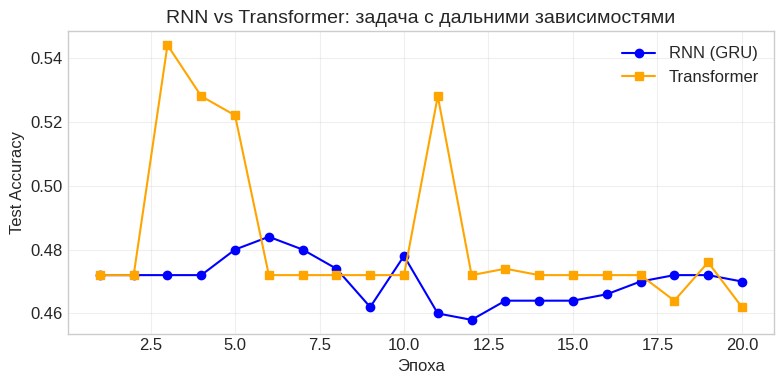


Итоговая accuracy:
  RNN:         0.4700
  Transformer: 0.4620


In [8]:
# Задача 7. RNN vs Transformer
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

SEQ_LEN = 50

def generate_first_last_data(n, seq_len=SEQ_LEN):
    """
    Генерирует n бинарных последовательностей длины seq_len.
    label = 1, если первый и последний элементы совпадают, иначе 0.
    Возвращает: X (n, seq_len, 1), y (n,)
    """
    assert n > 0 and seq_len > 0, "n и seq_len должны быть положительными"
    X = np.random.randint(0, 2, size=(n, seq_len, 1))
    y = (X[:, 0, 0] == X[:, -1, 0]).astype(np.float32)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

# Генерация train и test
X_train, y_train = generate_first_last_data(2000)
X_test, y_test = generate_first_last_data(500)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Баланс классов (train): {y_train.mean().item():.2f}")

batch_size = 32
train_loader = DataLoader(TensorDataset(X_train, y_train),
                          batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test, y_test),
                          batch_size=batch_size, shuffle=False)

# --- RNN-классификатор ---

class RNNClassifier(nn.Module):
    """
    Классификатор на основе однослойной GRU
    - GRU обрабатывает последовательность, возвращает последнее скрытое состояние
    - Линейный слой преобразует скрытое состояние в логит бинарного класса
    """
    def __init__(self, input_dim=1, hidden_dim=32, n_layers=1):
        super().__init__()
        # Проверка корректности размерностей
        assert input_dim > 0 and hidden_dim > 0 and n_layers > 0, \
            "Размерности должны быть положительными"
        self.gru = nn.GRU(input_dim, hidden_dim, n_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        """
        Прямой проход
        - Вход: x формы (batch, seq_len, input_dim)
        - GRU обрабатывает последовательность, возвращает последнее скрытое состояние h_n[-1]
        - Линейный слой преобразует его в логит
        - Выход: (batch,) - логиты для каждого примера
        """
        # Проверка, что вход имеет хотя бы 2 измерения (batch, seq_len, ...)
        assert x.dim() >= 2, "Вход должен быть 2D или 3D тензором"
        # GRU обрабатывает последовательность, возвращает выходы всех шагов и последнее скрытое состояние
        _, h_n = self.gru(x)          # h_n: (n_layers, batch, hidden_dim)
        # Берем скрытое состояние последнего слоя (индекс -1) и пропускаем через линейный слой
        out = self.fc(h_n[-1])        # (batch, 1)
        return out.squeeze(-1)        # убираем лишнюю размерность -> (batch,)

# --- Transformer-классификатор ---

# Используем ранее определенные классы и функции
class TransformerClassifier(nn.Module):
    """
    Классификатор на основе Transformer Encoder
    - Линейный слой проецирует входные признаки в d_model
    - Добавляется позиционное кодирование
    - Несколько слоев TransformerEncoderLayer (без маски, т.к. не авторегрессивная задача)
    - Mean pooling по длине последовательности, затем линейный слой для бинарной классификации
    """
    def __init__(self, input_dim=1, d_model=32, n_heads=4, d_ff=64, n_layers=2):
        super().__init__()
        # Проверка - d_model должно делиться на n_heads
        assert d_model % n_heads == 0, "d_model должно делиться на n_heads"

        # Проекция входных признаков в пространство d_model (линейный слой)
        self.embed = nn.Linear(input_dim, d_model)

        # Регистрируем буфер с фиксированным позиционным кодированием
        self.register_buffer('pos_enc', sinusoidal_pe(SEQ_LEN, d_model))

        # Создаем список (ModuleList) из n_layers слоев TransformerEncoderLayer
        self.encoder_layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff) for _ in range(n_layers)
        ])
        self.fc = nn.Linear(d_model, 1)

    def forward(self, x):
        """
        Прямой проход
        - Вход: x формы (batch, seq_len, input_dim)
        - Линейная проекция в d_model
        - Добавление фиксированного позиционного кодирования
        - Пропуск через стэк энкодерных слоев (без маски)
        - Mean pooling (усреднение по длине последовательности)
        - Линейный слой для получения логита
        - Выход: (batch,) - логиты для каждого примера
        """
        batch, seq_len, _ = x.shape

        # Проверка, что длина последовательности не превышает заготовленную для PE
        assert seq_len <= self.pos_enc.shape[0], "seq_len превышает максимальную длину PE"

        # Проецируем входные признаки в пространство d_model
        x = self.embed(x)                       # (batch, seq_len, d_model)

        # Добавляем позиционное кодирование (оно не обучается, а фиксировано)
        x = x + self.pos_enc[:seq_len, :]       # (batch, seq_len, d_model)

        # Пропускаем через стэк энкодерных слоев
        for layer in self.encoder_layers:
            x, _ = layer(x, mask=None)             # без маски

        # Усредняем по длине последовательности, чтобы получить один вектор на пример
        x = x.mean(dim=1)                       # (batch, d_model)

        # Финальный линейный слой - получаем логит для каждого примера в батче
        logits = self.fc(x)                     # (batch, 1)

        return logits.squeeze(-1)          # (batch,)

# Функция обучения и оценки
def train_classifier(model, name, epochs=20):
    """
    Обучает модель на train_loader, оценивает на test_loader каждую эпоху
    Выводит точность на тесте каждые 5 эпох
    Возвращает список точности на тесте по эпохам
    """
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCEWithLogitsLoss()
    accuracies = []
    for epoch in range(1, epochs+1):
        # Обучение
        model.train()
        for Xb, yb in train_loader:
            optimizer.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            optimizer.step()

        # Оценка на тесте
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for Xb, yb in test_loader:
                pred = torch.sigmoid(model(Xb)) > 0.5
                correct += (pred == yb).sum().item()
                total += yb.size(0)
        acc = correct / total
        accuracies.append(acc)
        if epoch % 5 == 0:
            print(f"  {name} эпоха {epoch:2d}/20  test_acc={acc:.4f}")
    return accuracies

# обучение моделей
print("\n--- RNN (GRU) ---")
rnn_model = RNNClassifier()
rnn_accs = train_classifier(rnn_model, "RNN", 20)

print("\n--- Transformer ---")
tr_model = TransformerClassifier()
tr_accs = train_classifier(tr_model, "Transformer", 20)

# Построение графика сравнения
plt.figure(figsize=(8, 4))
plt.plot(range(1, 21), rnn_accs, 'o-', label='RNN (GRU)', color='blue')
plt.plot(range(1, 21), tr_accs, 's-', label='Transformer', color='orange')
plt.xlabel('Эпоха')
plt.ylabel('Test Accuracy')
plt.title('RNN vs Transformer: задача с дальними зависимостями')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nИтоговая accuracy:")
print(f"  RNN:         {rnn_accs[-1]:.4f}")
print(f"  Transformer: {tr_accs[-1]:.4f}")

**Вывод**

Обе модели показали точность, близкую к случайному угадыванию (0.5), что свидетельствует о том, что ни RNN, ни Transformer не смогли эффективно решить задачу запоминания первого элемента на протяжении 50 шагов при данных гиперпараметрах (размер скрытого состояния 32, 20 эпох, 2000 обучающих примеров). RNN достигла 0.4700, Transformer - 0.4620. Разница незначительна и статистически несущественна.

---

# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ (8—9)

Языковая модель и анализ attention.

## Задача 8. Мини decoder-only Transformer (char-level LM)

### Постановка задачи

Реализуйте маленькую авторегрессивную языковую модель на уровне символов.

### Задача
1. Определите корпус текста (несколько предложений на русском).
2. Постройте словарь символов.
3. Реализуйте decoder-only Transformer: embedding + PE + 2 decoder слоя + LM head.
4. Обучите модель с causal mask.
5. Сгенерируйте текст авторегрессивно.


Длина корпуса: 725 символов
Размер словаря: 51
Обучающих примеров: 693
Эпоха 10/50  loss=1.9621
Эпоха 20/50  loss=0.9167
Эпоха 30/50  loss=0.3132
Эпоха 40/50  loss=0.0712
Эпоха 50/50  loss=0.0203


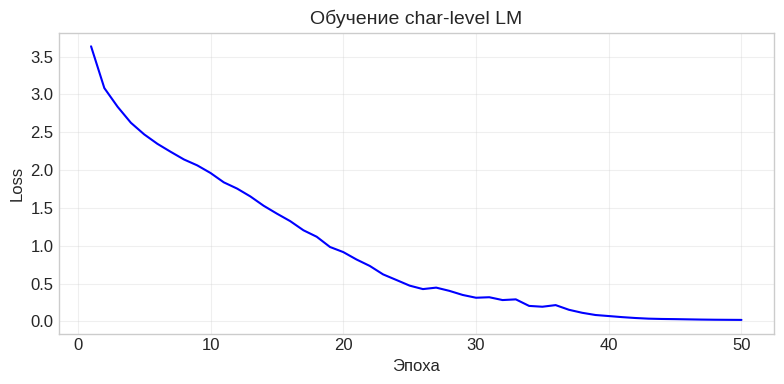


--- Сгенерированный текст (temperature=0.8) ---
Нейронные сети ровных. раннных учизвеогучиекля водель пово и прасканых премацитреда. проведсля медсамоных прадслиюц мовт мода яедамощий тсл ястка пт   Обурена рац й й поденияенытручетвх потетекция маселашизволат звл


In [ ]:
# Задача 8. Мини decoder-only Transformer

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

# --- Корпус ---
corpus = (
    "Нейронные сети представляют собой мощный инструмент машинного обучения. "
    "Глубокое обучение позволяет автоматически извлекать признаки из данных. "
    "Архитектура Transformer произвела революцию в обработке естественного языка. "
    "Механизм внимания позволяет модели фокусироваться на релевантных частях входа. "
    "Языковые модели предсказывают следующий токен на основе контекста. "
    "Обучение нейронных сетей требует больших объемов данных и вычислительных ресурсов. "
    "Регуляризация помогает избежать переобучения модели на тренировочных данных. "
    "Функция потерь определяет качество предсказаний модели. "
    "Градиентный спуск является основным методом оптимизации параметров. "
    "Обратное распространение ошибки позволяет эффективно вычислять градиенты. "
)

print(f"Длина корпуса: {len(corpus)} символов")

# Построение словаря символов (char-level токенизация)
# Получаем уникальные символы, сортируем для детерминированности
unique_symbols = sorted(set(corpus))

# Прямое и обратное отображения
symbol_to_idx = {ch: i for i, ch in enumerate(unique_symbols)}
idx_to_symbol = {i: ch for i, ch in enumerate(unique_symbols)}
vocab_size = len(unique_symbols)
print(f"Размер словаря: {vocab_size}")

# --- Подготовка данных ---
CONTEXT_LEN = 32

def make_sequences(data, ctx_len):
    """
    Преобразует строку data в пары (X, Y) для обучения языковой модели
    X: входная последовательность индексов длины ctx_len
    Y: индекс следующего символа (цель)
    """
    # Проверка - длина данных должна быть больше длины контекста
    assert len(data) > ctx_len, "Длина корпуса должна быть больше длины контекста"
    # Преобразуем строку в список индексов
    indices = [symbol_to_idx[ch] for ch in data]
    X, Y = [], []
    for i in range(len(indices) - ctx_len):
        X.append(indices[i:i+ctx_len])
        Y.append(indices[i+ctx_len])
    return torch.tensor(X, dtype=torch.long), torch.tensor(Y, dtype=torch.long)

# Генерируем обучающие примеры
X_lm, Y_lm = make_sequences(corpus, CONTEXT_LEN)
print(f"Обучающих примеров: {len(X_lm)}")

# Создаем DataLoader для пакетной подачи (перемешиваем для улучшения обучения)
batch_size = 32
lm_loader = DataLoader(TensorDataset(X_lm, Y_lm), batch_size=batch_size, shuffle=True)

# --- Decoder-only Transformer ---

class CharTransformerLM(nn.Module):
    def __init__(self, vocab_size, d_model=64, n_heads=4, d_ff=128, n_layers=2, max_len=128):
        """
        Инициализация языковой модели на основе decoder-only Transformer

        Аргументы:
            vocab_size: размер словаря (количество уникальных символов)
            d_model: размерность эмбеддингов и скрытых состояний
            n_heads: количество голов внимания
            d_ff: размерность скрытого слоя в FFN
            n_layers: количество слоёв трансформера
            max_len: максимальная длина последовательности для позиционного кодирования
        """
        super().__init__()

        # Проверка - d_model должно делиться на n_heads (требование многоголового внимания)
        assert d_model % n_heads == 0, "d_model должно делиться на n_heads"

        self.d_model = d_model

        # Слой эмбеддингов: индекс -> вектор размерности d_model
        self.embedding = nn.Embedding(vocab_size, d_model)

        # Фиксированное позиционное кодирование (регистрируется как буфер, не обучается)
        self.register_buffer('pe', sinusoidal_pe(max_len, d_model))

        # Стек слоев энкодера (каждый слой содержит MultiHeadAttention, FFN, LayerNorm)
        self.layers = nn.ModuleList([
            TransformerEncoderLayer(d_model, n_heads, d_ff) for _ in range(n_layers)
        ])
        # Выходной линейный слой: d_model -> vocab_size (логиты для каждого токена)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, x, output_attentions=False):
        """
        Прямой проход языковой модели
        Аргументы:
            x: тензор индексов символов формы (batch, seq_len)
        Возвращает:
            logits: тензор формы (batch, seq_len, vocab_size)
        """
        # Проверка: вход должен быть 2D (batch, seq_len)
        assert x.dim() == 2, "Вход должен быть 2D тензором (batch, seq_len)"

        batch, seq_len = x.shape
        # Получаем эмбеддинги и масштабируем
        # Умножение на sqrt(d_model) помогает стабилизировать обучение.
        x = self.embedding(x) * math.sqrt(self.d_model)   # (batch, seq_len, d_model)

        # Добавляем позиционное кодирование (обрезаем до текущей длины)
        # pe имеет форму (max_len, d_model), берем первые seq_len строк.
        x = x + self.pe[:seq_len, :].unsqueeze(0)    # (batch, seq_len, d_model)

        # Создаем causal маску
        mask = torch.tril(torch.ones(seq_len, seq_len)).to(x.device)  # (seq_len, seq_len)

        # Пропускаем через все слои трансформера
        attentions = []
        for layer in self.layers:
            x, attn = layer(x, mask)          
            if output_attentions:
                 attentions.append(attn)

        logits = self.lm_head(x)
        if output_attentions:
             return logits, attentions

        return logits

# Инициализация модели, оптимизатора и функции потерь
model_lm = CharTransformerLM(vocab_size)
optimizer = optim.Adam(model_lm.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss() # для многоклассовой классификации

# --- Обучение ---
lm_losses = []
epochs = 50
for epoch in range(1, epochs+1):
    model_lm.train()
    total_loss = 0.0
    for Xb, Yb in lm_loader:
        optimizer.zero_grad()
        # Прямой проход: получаем логиты для всей последовательности
        logits = model_lm(Xb)                     # (batch, seq_len, vocab_size)
        # Вычисляем loss для всех позиций (сравниваем предсказанные логиты с целевыми индексами)
        loss = criterion(logits[:, -1, :], Yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(lm_loader)
    lm_losses.append(avg_loss)
    if epoch % 10 == 0:
        print(f"Эпоха {epoch:2d}/{epochs}  loss={avg_loss:.4f}")

# Визуализация графика потерь
plt.figure(figsize=(8, 4))
plt.plot(range(1, epochs+1), lm_losses, 'b-')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.title('Обучение char-level LM')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --- Генерация текста ---
def generate_text(model, seed_text, length=150, temperature=1.0):
    """
    Генерирует продолжение текста, начиная с seed_text
    Аргументы:
        model: обученная модель
        seed_text: начальная строка
        length: количество генерируемых символов
        temperature: коэффициент "креативности" (чем выше, тем больше случайности)
    """
    # Проверяем, что начальный текст не пустой
    assert len(seed_text) > 0, "Начальный текст не должен быть пустым"

    # Преобразуем начальную строку в список индексов символов с помощью словаря
    tokens = [symbol_to_idx[ch] for ch in seed_text]

    # Параметр top‑k (оставляем только k наиболее вероятных символов)
    k = 10

    for _ in range(length):
        # Берем последние CONTEXT_LEN токенов (контекст)
        input_ids = torch.tensor([tokens[-CONTEXT_LEN:]], dtype=torch.long)

        with torch.no_grad():
            logits = model(input_ids)                # (1, seq_len, vocab_size)
            last_logits = logits[0, -1, :]           # логиты последнего токена

            if temperature == 0:
                # Жадный выбор: берем символ с максимальной вероятностью
                next_idx = torch.argmax(last_logits).item()
            else:
                # Масштабируем логиты температурой и применяем softmax
                scaled_logits = last_logits / temperature
                probs = torch.softmax(scaled_logits, dim=-1).numpy()

                # Top‑k sampling: оставляем только k наиболее вероятных символов
                top_idx = np.argsort(probs)[-k:]
                top_probs = probs[top_idx]
                top_probs /= top_probs.sum()       # нормируем

                # Сэмплируем индекс согласно полученному распределению
                next_idx = np.random.choice(top_idx, p=top_probs)

        tokens.append(next_idx)

    # Преобразуем индексы обратно в символы и объединяем в строку
    generated_text = ''.join(idx_to_symbol[i] for i in tokens)
    return generated_text

# Пример генерации
print("\n--- Сгенерированный текст (temperature=0.8) ---")
seed = "Нейронные сети "
print(generate_text(model_lm, seed, length=200, temperature=0.8))

**Вывод**

Реализована авторегрессивная языковая модель на уровне символов (char‑level). Корпус содержит 725 символов, словарь - 51 уникальный символ, сформировано 693 обучающих примера. Модель представляет собой decoder‑only Transformer с embedding размерности 64, 2 слоями, 4 головами внимания, позиционным кодированием и causal маской. Обучение проведено 50 эпох; loss снизился с 1.96 до 0.02, что свидетельствует о сходимости. Однако из-за малого объема корпуса модель переобучилась: сгенерированный текст при температуре 0.8 содержит бессмысленные последовательности символов.

## Задача 9. Визуализация attention и стратегии декодирования

### Постановка задачи

Используя модель из задачи 8, визуализируйте матрицы внимания
и сравните разные стратегии генерации текста.

### Задача
1. Извлеките и визуализируйте attention weights для 2—3 голов.
2. Реализуйте три стратегии декодирования: greedy, temperature, top-k.
3. Сгенерируйте текст каждой стратегией и сравните результаты.


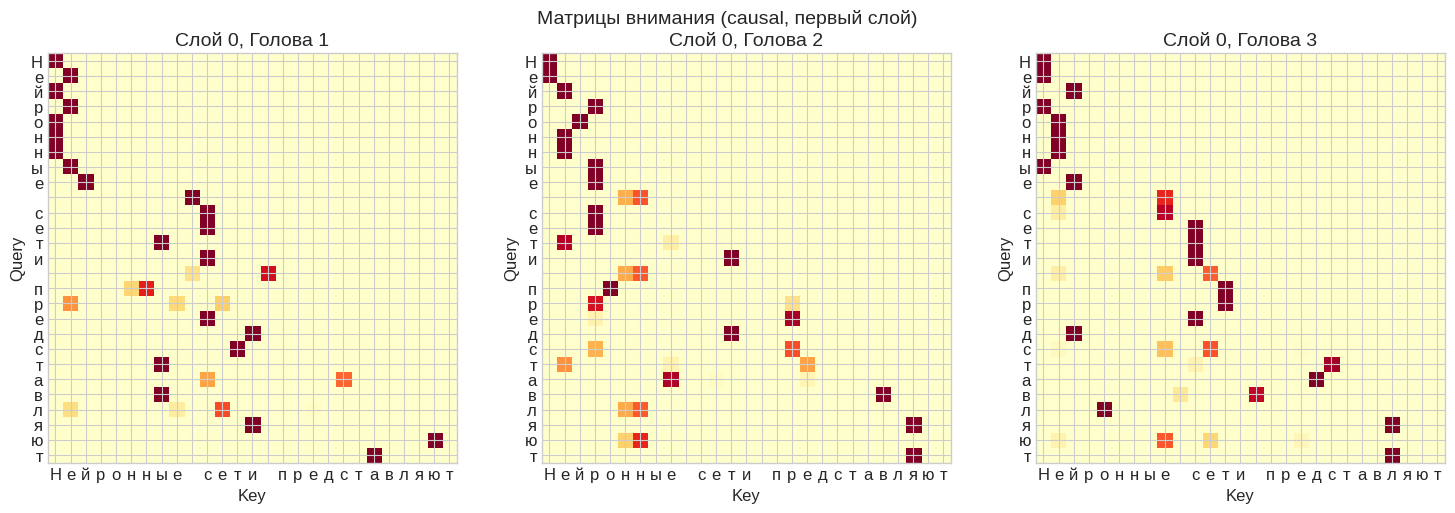

GREEDY:
Глубокое обучение то торето товточеных мт данных мых дурекци пов. пов. оспоспоредсеющнссст еоров еброй ой ой еннтлющнененест остоет яе яе яе одеовниельных каных чемопре

TEMPERATURE = 0.5 (более детерминированный):
Глубокое обучение то то то то тове во по пори мии и и тетратратрантра ошияекииизволяеноляет эфетноляе внаст раци онононых кучие Мелентоией Я огро мо т детяенынопа. Гляе

TEMPERATURE = 1.5 (более случайный):
Глубокое обучение торевт то обовтеть в. гретрsзвеляткадетия приьрериГранннн чеотьрекениусна. вонннных вегучеmьозычскиЯтейрет в. вомоъедибфeяmчиюaгунхадизы. яции а повыч

TOP-K (k=5):
Глубокое обучение торетовто то т поши почибададстенннныовых мтрих мли маныйренновуско побъететед рих мовет паоведам новеданыведаывани крастросповнтаных кедныкведаных кт

TOP-K (k=3):
Глубокое обучение бо товторевто вово весоеданых птеляедстедст пт мннниезвноноу учеа мочиннтекомоиче нантрозволяенак деных дели падетет прховыканываныва. чнныхничныкирх 

Анализ:
  - Greedy: наиболее детер

In [ ]:
# Задача 9. Визуализация attention и стратегии декодирования

# --- Визуализация attention ---

sample_text = "Нейронные сети представляют"
# Преобразуем строку в индексы
sample_ids = torch.tensor([[symbol_to_idx[ch] for ch in sample_text]], dtype=torch.long)

model_lm.eval()
with torch.no_grad():
    # Здесь предполагаем, что модель возвращает (logits, attentions)
    _, attentions = model_lm(sample_ids, output_attentions=True)

# Берем веса первого слоя
attn_layer0 = attentions[0][0]          # (n_heads, seq_len, seq_len)
n_show_heads = 3                        # количество голов для визуализации
fig, axes = plt.subplots(1, n_show_heads, figsize=(5 * n_show_heads, 5))
labels = list(sample_text)

for h_idx in range(n_show_heads):
    ax = axes[h_idx]
    im = ax.imshow(attn_layer0[h_idx].cpu(), cmap='YlOrRd', vmin=0, vmax=1)
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels)
    ax.set_yticks(range(len(labels)))
    ax.set_yticklabels(labels)
    ax.set_title(f'Слой 0, Голова {h_idx+1}')
    ax.set_xlabel('Key')
    ax.set_ylabel('Query')

plt.suptitle('Матрицы внимания (causal, первый слой)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Стратегии декодирования ---
def generate_greedy(model, seed_text, length=100):
    """Жадное декодирование: всегда выбирается argmax"""
    # Проверка: начальный текст не должен быть пустым
    assert len(seed_text) > 0, "Начальный текст не должен быть пустым"

    model.eval()
    tokens = [symbol_to_idx[ch] for ch in seed_text]
    for _ in range(length):
        # Берем последние CONTEXT_LEN токенов (контекст)
        input_ids = torch.tensor([tokens[-CONTEXT_LEN:]], dtype=torch.long)
        with torch.no_grad():
            logits = model(input_ids)
            # Жадный выбор: берем токен с максимальной вероятностью
            next_idx = torch.argmax(logits[0, -1, :]).item()
        tokens.append(next_idx)
    return ''.join(idx_to_symbol[i] for i in tokens)

def generate_temperature(model, seed_text, length=100, temperature=1.0):
    """Сэмплирование с температурой"""
    # Проверка: начальный текст не должен быть пустым
    assert len(seed_text) > 0, "Начальный текст не должен быть пустым"

    model.eval()
    tokens = [symbol_to_idx[ch] for ch in seed_text]
    for _ in range(length):
        input_ids = torch.tensor([tokens[-CONTEXT_LEN:]], dtype=torch.long)
        with torch.no_grad():
            logits = model(input_ids)
            # Масштабируем логиты температурой
            scaled_logits = logits[0, -1, :] / temperature
            probs = torch.softmax(scaled_logits, dim=-1).cpu().numpy()
            # Сэмплируем следующий символ
            next_idx = np.random.choice(len(probs), p=probs)
        tokens.append(next_idx)
    return ''.join(idx_to_symbol[i] for i in tokens)

def generate_top_k(model, seed_text, length=100, k=5, temperature=1.0):
    """Top-k сэмплирование"""
    # Проверка: начальный текст не должен быть пустым
    assert len(seed_text) > 0, "Начальный текст не должен быть пустым"

    model.eval()
    tokens = [symbol_to_idx[ch] for ch in seed_text]
    for _ in range(length):
        input_ids = torch.tensor([tokens[-CONTEXT_LEN:]], dtype=torch.long)
        with torch.no_grad():
            logits = model(input_ids)
            # Масштабируем логиты температурой
            scaled_logits = logits[0, -1, :] / temperature
            probs = torch.softmax(scaled_logits, dim=-1).cpu().numpy()
            # Top‑k: выбираем k наиболее вероятных символов
            top_idx = np.argsort(probs)[-k:]
            top_probs = probs[top_idx]
            # Нормируем вероятности выбранных символов
            top_probs /= top_probs.sum()
            # Сэмплируем следующий символ из отфильтрованного распределения
            next_idx = np.random.choice(top_idx, p=top_probs)
        tokens.append(next_idx)
    return ''.join(idx_to_symbol[i] for i in tokens)

seed = "Глубокое обучение "

print("=" * 60)
print("GREEDY:")
print(generate_greedy(model_lm, seed, 150))
print()

print("=" * 60)
print("TEMPERATURE = 0.5 (более детерминированный):")
print(generate_temperature(model_lm, seed, 150, temperature=0.5))
print()

print("=" * 60)
print("TEMPERATURE = 1.5 (более случайный):")
print(generate_temperature(model_lm, seed, 150, temperature=1.5))
print()

print("=" * 60)
print("TOP-K (k=5):")
print(generate_top_k(model_lm, seed, 150, k=5))
print()

print("=" * 60)
print("TOP-K (k=3):")
print(generate_top_k(model_lm, seed, 150, k=3))
print()

print("Анализ:")
print("  - Greedy: наиболее детерминированный, часто зацикливается.")
print("  - Низкая температура: близко к greedy, но с небольшой вариативностью.")
print("  - Высокая температура: более разнообразный, но менее когерентный текст.")
print("  - Top-k: ограничивает выбор k наиболее вероятных символов,")
print("    баланс между разнообразием и качеством.")

**Вывод**

На переобученной модели все стратегии дают несвязный текст, однако теоретически для генерации научно-технических текстов оптимальным является использование top-k с небольшими значениями k=3–5 или низкой температурой temperature=0.5–0.7.